
**Boston Housing Regression with Perceptron**

## Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Set Seed

In [2]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


Device: cuda


## Load Data

In [3]:
columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]

def load_boston_data():
    try:
        from sklearn.datasets import load_boston

        data = load_boston()

        df = pd.DataFrame(data.data, columns=data.feature_names)
        df["MEDV"] = data.target

        return df

    except Exception:
        try:
            from sklearn.datasets import fetch_openml

            data = fetch_openml(
                name="boston",
                version=1,
                as_frame=True
            )

            df = data.frame.copy()

            for col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

            if "MEDV" not in df.columns:
                df["MEDV"] = pd.to_numeric(data.target, errors="coerce")

            return df.dropna().reset_index(drop=True)

        except Exception:
            url = "http://lib.stat.cmu.edu/datasets/boston"

            raw = pd.read_csv(
                url,
                sep=r"\s+",
                skiprows=22,
                header=None
            )

            X = np.hstack([
                raw.values[::2, :],
                raw.values[1::2, :2]
            ])

            y = raw.values[1::2, 2]

            df = pd.DataFrame(X, columns=columns)
            df["MEDV"] = y

            return df

df = load_boston_data()

print(df.shape)
df.head()


(506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Data Info

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


## Data Split

In [5]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


Train: (354, 14)
Validation: (76, 14)
Test: (76, 14)


## Train Correlation

In [6]:
correlations = (
    train_df
    .corr(numeric_only=True)["MEDV"]
    .sort_values(ascending=False)
)

print(correlations)


MEDV       1.000000
RM         0.698491
ZN         0.329526
B          0.324991
DIS        0.241323
CHAS       0.226487
AGE       -0.350505
CRIM      -0.380453
RAD       -0.384704
NOX       -0.406677
TAX       -0.452308
INDUS     -0.459568
PTRATIO   -0.492096
LSTAT     -0.747107
Name: MEDV, dtype: float64


## Select Features

In [7]:
features = ["RM", "AGE"]
target = "MEDV"

X_train = train_df[features].values.astype(np.float32)
y_train = train_df[target].values.astype(np.float32).reshape(-1, 1)

X_val = val_df[features].values.astype(np.float32)
y_val = val_df[target].values.astype(np.float32).reshape(-1, 1)

X_test = test_df[features].values.astype(np.float32)
y_test = test_df[target].values.astype(np.float32).reshape(-1, 1)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)


(354, 2) (354, 1)
(76, 2) (76, 1)
(76, 2) (76, 1)


## Feature Plot

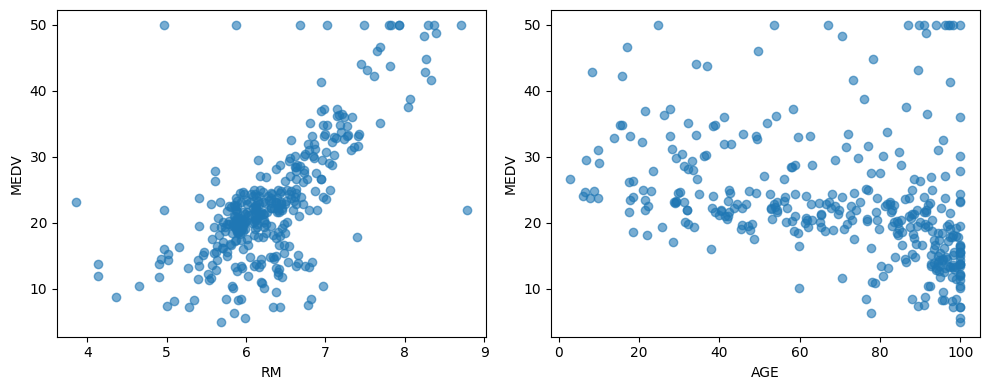

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(X_train[:, 0], y_train.ravel(), alpha=0.6)
axes[0].set_xlabel("RM")
axes[0].set_ylabel("MEDV")

axes[1].scatter(X_train[:, 1], y_train.ravel(), alpha=0.6)
axes[1].set_xlabel("AGE")
axes[1].set_ylabel("MEDV")

plt.tight_layout()
plt.show()


## Scale Data

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)


## Data Loaders

In [10]:
train_data = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train)
)

val_data = TensorDataset(
    torch.from_numpy(X_val),
    torch.from_numpy(y_val)
)

test_data = TensorDataset(
    torch.from_numpy(X_test),
    torch.from_numpy(y_test)
)

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)


## Perceptron Model

In [11]:
class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, x):
        return self.linear(x)

model = Perceptron().to(device)

print(model)


Perceptron(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)


## Training Setup

In [12]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.05
)

epochs = 400


## Validation Loss

In [13]:
def get_loss(loader):
    model.eval()

    total_loss = 0
    total_count = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = loss_fn(pred, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            total_count += X_batch.size(0)

    return total_loss / total_count


## Train Model

In [14]:
train_loss = []
val_loss = []

for epoch in range(epochs):
    model.train()

    total_loss = 0
    total_count = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        total_count += X_batch.size(0)

    train_loss.append(total_loss / total_count)
    val_loss.append(get_loss(val_loader))

    if (epoch + 1) % 40 == 0:
        print(
            epoch + 1,
            round(train_loss[-1], 4),
            round(val_loss[-1], 4)
        )


40 75.7259 42.4075
80 42.1146 14.7425
120 41.6685 14.9213
160 41.7014 14.8467
200 41.6486 15.1293
240 41.753 14.7521
280 41.7208 15.4973
320 41.8407 15.1495
360 41.6791 15.3372
400 41.7007 15.3466


## Loss Plot

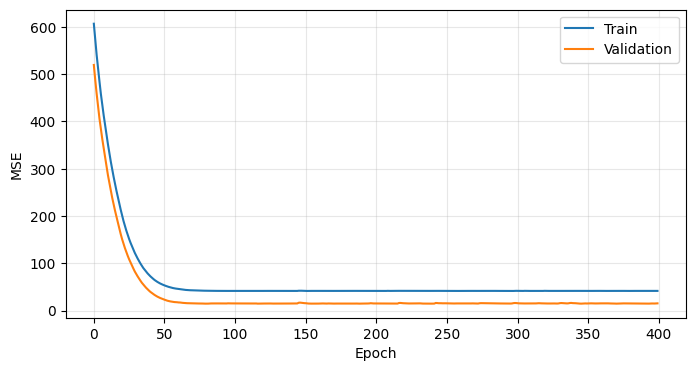

In [15]:
plt.figure(figsize=(8, 4))

plt.plot(train_loss, label="Train")
plt.plot(val_loss, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


## Test Prediction

In [16]:
model.eval()

with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_test).to(device)
    y_pred = model(X_test_tensor).cpu().numpy()


## Test Metrics

In [17]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("MAE:", round(mae, 4))
print("R2:", round(r2, 4))


MSE: 54.7794
RMSE: 7.4013
MAE: 5.1505
R2: 0.3108


## Model Parameters

In [18]:
weights = model.linear.weight.detach().cpu().numpy().ravel()
bias = model.linear.bias.detach().cpu().numpy().item()

print("RM weight:", round(float(weights[0]), 4))
print("AGE weight:", round(float(weights[1]), 4))
print("Bias:", round(float(bias), 4))


RM weight: 5.9702
AGE weight: -2.0228
Bias: 22.9597


## Prediction Plane

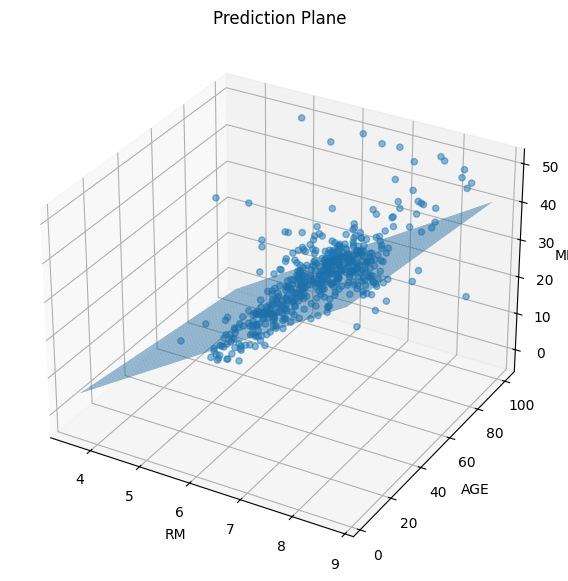

In [19]:
X_all = df[features].values.astype(np.float32)
y_all = df[target].values.astype(np.float32)

grid_rm = np.linspace(
    X_all[:, 0].min(),
    X_all[:, 0].max(),
    50
)

grid_age = np.linspace(
    X_all[:, 1].min(),
    X_all[:, 1].max(),
    50
)

rm_grid, age_grid = np.meshgrid(
    grid_rm,
    grid_age
)

grid_points = np.column_stack([
    rm_grid.ravel(),
    age_grid.ravel()
]).astype(np.float32)

grid_scaled = scaler.transform(
    grid_points
).astype(np.float32)

model.eval()

with torch.no_grad():
    grid_pred = model(
        torch.from_numpy(grid_scaled).to(device)
    ).cpu().numpy()

price_grid = grid_pred.reshape(
    rm_grid.shape
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_all[:, 0],
    X_all[:, 1],
    y_all,
    alpha=0.5,
    label="Data"
)

ax.plot_surface(
    rm_grid,
    age_grid,
    price_grid,
    alpha=0.5
)

ax.set_xlabel("RM")
ax.set_ylabel("AGE")
ax.set_zlabel("MEDV")

ax.set_title("Prediction Plane")

plt.show()


## Actual Prediction

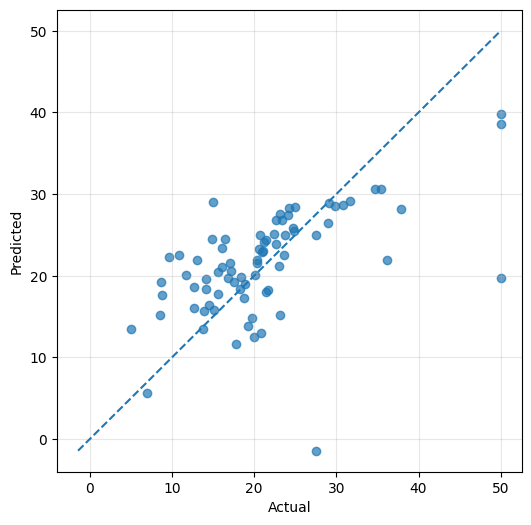

In [20]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test.ravel(),
    y_pred.ravel(),
    alpha=0.7
)

low = min(
    y_test.min(),
    y_pred.min()
)

high = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [low, high],
    [low, high],
    "--"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(alpha=0.3)

plt.show()


## Save Model

In [21]:
os.makedirs("outputs", exist_ok=True)

torch.save(
    model.state_dict(),
    "outputs/perceptron_boston.pth"
)


## GitHub Link

Add repository URL.